In [1]:
import torch
import pickle
import os

checkpoint_path = 'checkpoints/exp_contrastive_triplet_hard_samples.pt'
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)#['model_state_dict']

In [2]:
checkpoint.keys()

dict_keys(['model_state_dict', 'node2vec_embeddings', 'node2vec_dim', 'graph_based_dim', 'num_classes', 'embed_dim', 'best_val_f1', 'test_f1', 'labels'])

In [3]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Dataset, Data, Batch
from torch_geometric.loader import DataListLoader
from torch_geometric.nn import TAGConv, GraphNorm
from collections import defaultdict
import igraph as ig
import random
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


/home/nchervov/big_data/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda:0


In [4]:
# Load splits and data
SPLITS_DIR = 'splits'

train_nodes = np.load(os.path.join(SPLITS_DIR, 'train_nodes.npy')).tolist()
val_nodes = np.load(os.path.join(SPLITS_DIR, 'val_nodes.npy')).tolist()
test_nodes = np.load(os.path.join(SPLITS_DIR, 'test_nodes.npy')).tolist()
unknown_nodes = np.load(os.path.join(SPLITS_DIR, 'unknown_nodes.npy')).tolist()
node_labels = np.load(os.path.join(SPLITS_DIR, 'node_labels_masked.npy'))

with open(os.path.join(SPLITS_DIR, 'labels.txt'), 'r') as f:
    labels = [line.strip() for line in f]

with open(os.path.join(SPLITS_DIR, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

max_node = metadata['max_node']
print(f"Labels: {labels}")
print(f"Train nodes: {len(train_nodes)}, Val nodes: {len(val_nodes)}, Test nodes: {len(test_nodes)}")

node_class = np.zeros((max_node + 1, len(labels)))
for n in range(max_node + 1):
    if node_labels[n] >= 0:
        node_class[n, node_labels[n]] = 1
    else:
        node_class[n, :] = np.ones(len(labels)) / len(labels)

train_nodes_by_class = {c: [] for c in range(len(labels))}
for n in train_nodes:
    if node_labels[n] >= 0:
        train_nodes_by_class[node_labels[n]].append(n)

# Load edge data
data = pd.read_csv('CR_real_masks_more_labeled_veritices_agreed.csv')
data['node_id1'] -= 1
data['node_id2'] -= 1

# Unknown nodes subset
random.seed(42)
unknown_nodes_shuffled = unknown_nodes.copy()
random.shuffle(unknown_nodes_shuffled)
NUM_UNKNOWN_FRACTION = 0.05
num_unknown_to_use = int(len(unknown_nodes_shuffled) * NUM_UNKNOWN_FRACTION)
unknown_nodes_subset = unknown_nodes_shuffled[:num_unknown_to_use]
print(f"Using {num_unknown_to_use} unknown nodes")


Labels: ['Belarusians', 'Northen Russians', 'Southern Russians', 'Ukranians']
Train nodes: 2779, Val nodes: 927, Test nodes: 927
Using 11312 unknown nodes


In [5]:
# Get params from checkpoint
node2vec_embeddings = checkpoint['node2vec_embeddings']
NODE2VEC_DIM = checkpoint['node2vec_dim']
GRAPH_BASED_DIM = checkpoint['graph_based_dim']
NUM_CLASSES = checkpoint['num_classes']
EMBED_DIM = checkpoint['embed_dim']

print(f"Node2Vec dim: {NODE2VEC_DIM}")
print(f"Graph-based dim: {GRAPH_BASED_DIM}")
print(f"Num classes: {NUM_CLASSES}")
print(f"Embed dim: {EMBED_DIM}")
print(f"Best val F1: {checkpoint['best_val_f1']:.4f}")
print(f"Test F1: {checkpoint['test_f1']:.4f}")


Node2Vec dim: 32
Graph-based dim: 26
Num classes: 4
Embed dim: 512
Best val F1: 0.6618
Test F1: 0.0652


In [6]:
def compute_graph_based_features(sorted_nodes, subgraph_edges, node_class_input, num_classes):
    num_nodes = len(sorted_nodes)
    node_mapping = {node: i for i, node in enumerate(sorted_nodes)}
    node_class_subset = node_class_input[sorted_nodes]
    node_labels_arr = np.argmax(node_class_subset, axis=1)
    node_labels_arr[np.max(node_class_subset, axis=1) <= 0.5] = -1

    features = np.zeros((num_nodes, 5 * num_classes + 6), dtype=np.float32)
    
    weights_per_node_class = defaultdict(list)
    edges = subgraph_edges[['node_id1', 'node_id2', 'ibd_sum']].values
    
    adj_list = defaultdict(list)
    edge_list = []
    
    for n1, n2, w in edges:
        if n1 in node_mapping and n2 in node_mapping:
            i, j = node_mapping[n1], node_mapping[n2]
            adj_list[i].append((j, w))
            adj_list[j].append((i, w))
            edge_list.append((i, j, w))

            c_j, c_i = node_labels_arr[j], node_labels_arr[i]
            if c_j >= 0:
                features[i, c_j] += 1
                features[i, num_classes + c_j] += w
                features[i, 3*num_classes + c_j] = max(features[i, 3*num_classes + c_j], w)
                features[i, 4*num_classes + c_j] += w
                weights_per_node_class[(i, c_j)].append(w)
            if c_i >= 0:
                features[j, c_i] += 1
                features[j, num_classes + c_i] += w
                features[j, 3*num_classes + c_i] = max(features[j, 3*num_classes + c_i], w)
                features[j, 4*num_classes + c_i] += w
                weights_per_node_class[(j, c_i)].append(w)
    
    count_mask = features[:, :num_classes] > 0
    features[:, num_classes:2*num_classes][count_mask] /= features[:, :num_classes][count_mask]
    
    for (i, c), weights in weights_per_node_class.items():
        if len(weights) > 1:
            features[i, 2*num_classes + c] = np.std(weights, dtype=np.float32)
    
    base_idx = 5 * num_classes
    
    for i in range(num_nodes):
        features[i, base_idx] = len(adj_list[i])
    
    for i in range(num_nodes):
        features[i, base_idx + 1] = sum(w for _, w in adj_list[i])
    
    g = ig.Graph()
    g.add_vertices(num_nodes)
    edges_ig = []
    weights_ig = []
    edge_weight_dict = defaultdict(float)
    for i, j, w in edge_list:   
        if i != j:
            key = (min(i, j), max(i, j))
            edge_weight_dict[key] += w

    for (i, j), w in edge_weight_dict.items():
        edges_ig.append((i, j))
        weights_ig.append(w)
    
    g.add_edges(edges_ig)
    g.es['weight'] = weights_ig

    clustering = g.transitivity_local_undirected()
    clustering_array = np.array(clustering, dtype=np.float32)
    is_nan = np.isnan(clustering_array)
    clustering_array[is_nan] = 0
    features[:, base_idx + 2] = clustering_array
    features[:, base_idx + 3] = is_nan.astype(np.float32)

    pagerank = g.pagerank(weights='weight')
    features[:, base_idx + 4] = np.array(pagerank, dtype=np.float32)

    return torch.tensor(features, dtype=torch.float32)


In [7]:
class TripletGraphDataset(Dataset):
    def __init__(self, data_df, unknown_nodes_subset, train_nodes, val_nodes, test_nodes,
                 train_nodes_by_class, node2vec_embeddings, node2vec_dim, n_classes,
                 split='train', num_mask_nodes=64, num_samples=500, 
                 mask_count=64, return_node_ids=False):
        super().__init__()
        self.data_df = data_df
        self.unknown_nodes_subset = unknown_nodes_subset
        self.train_nodes = train_nodes
        self.val_nodes = val_nodes
        self.test_nodes = test_nodes
        self.train_nodes_by_class = train_nodes_by_class
        self.node2vec_embeddings = node2vec_embeddings
        self.node2vec_dim = node2vec_dim
        self.n_classes = n_classes
        self.graph_based_dim = 5 * n_classes + 6
        self.split = split
        self.num_mask_nodes = num_mask_nodes
        self.num_samples = num_samples
        self.mask_count = mask_count
        self.return_node_ids = return_node_ids

        if split == 'train':
            self.target_nodes = train_nodes
        elif split == 'train_eval':
            self.target_nodes = train_nodes
        elif split == 'val':
            self.target_nodes = val_nodes
        else:
            self.target_nodes = test_nodes

    def len(self):
        if self.split == 'train':
            return self.num_samples
        else:
            return (len(self.target_nodes) + self.mask_count - 1) // self.mask_count

    def get(self, idx):
        nodes_to_include = self.train_nodes.copy()
        nodes_to_include.extend(self.unknown_nodes_subset)

        if self.split == 'train':
            mask_nodes = []
            classes = [c for c in self.train_nodes_by_class.keys() if len(self.train_nodes_by_class[c]) >= 2]
            nodes_per_class = max(2, self.num_mask_nodes // len(classes))
            for c in classes:
                available = self.train_nodes_by_class[c]
                sample_size = min(nodes_per_class, len(available))
                mask_nodes.extend(random.sample(available, sample_size))
            random.shuffle(mask_nodes)
            mask_nodes = mask_nodes[:self.num_mask_nodes]
        else:
            start_idx = idx * self.mask_count
            end_idx = min(start_idx + self.mask_count, len(self.target_nodes))
            mask_nodes = self.target_nodes[start_idx:end_idx]
            for n in mask_nodes:
                if n not in nodes_to_include:
                    nodes_to_include.append(n)

        nodes_set = set(nodes_to_include)
        mask = (self.data_df['node_id1'].isin(nodes_set) & self.data_df['node_id2'].isin(nodes_set))
        subgraph_edges = self.data_df[mask]

        if len(subgraph_edges) == 0:
            return None

        sorted_nodes = sorted(nodes_to_include)
        node_mapping = {node: i for i, node in enumerate(sorted_nodes)}

        src = [node_mapping[n] for n in subgraph_edges['node_id1'].values]
        dst = [node_mapping[n] for n in subgraph_edges['node_id2'].values]
        edge_index = torch.tensor([src + dst, dst + src], dtype=torch.long)

        mask_indices = [node_mapping[n] for n in mask_nodes if n in node_mapping]
        predict_mask = torch.zeros(len(sorted_nodes), dtype=torch.bool)
        predict_mask[mask_indices] = True

        # Node2Vec embeddings
        node2vec_features = np.zeros((len(sorted_nodes), self.node2vec_dim), dtype=np.float32)
        use_query_mask = torch.zeros(len(sorted_nodes), dtype=torch.bool)
        
        mask_nodes_set = set(mask_nodes)
        for i, node in enumerate(sorted_nodes):
            if node in mask_nodes_set:
                use_query_mask[i] = True
            elif node in self.node2vec_embeddings:
                node2vec_features[i] = self.node2vec_embeddings[node]
        
        node2vec_features = torch.tensor(node2vec_features, dtype=torch.float32)

        # Graph-based features (with masking)
        node_class_masked = node_class.copy()
        for n in mask_nodes:
            node_class_masked[n, :] = np.ones(self.n_classes) / self.n_classes
        
        graph_features = compute_graph_based_features(sorted_nodes, subgraph_edges, node_class_masked, self.n_classes)

        # One-hot class features (masked)
        onehot_masked = torch.tensor(node_class_masked[sorted_nodes], dtype=torch.float)

        # Combine all features
        node_features = torch.cat([node2vec_features, graph_features, onehot_masked], dim=1)

        # Labels (ground truth)
        onehot = torch.tensor(node_class[sorted_nodes], dtype=torch.float)
        y = torch.tensor([torch.argmax(onehot[i]).item() for i in range(len(sorted_nodes))], dtype=torch.long)

        # Edge weights
        ibd = subgraph_edges['ibd_sum'].values
        edge_weights = torch.tensor(list(ibd) + list(ibd), dtype=torch.float)

        if self.return_node_ids:
            masked_node_ids = torch.tensor([mask_nodes[mask_indices.index(i)] for i in mask_indices], dtype=torch.long)
            return Data(
                x=node_features, edge_index=edge_index, y=y, weight=edge_weights,
                n_classes=self.n_classes, predict_mask=predict_mask, 
                use_query_mask=use_query_mask, masked_node_ids=masked_node_ids
            )

        return Data(
            x=node_features, edge_index=edge_index, y=y, weight=edge_weights,
            n_classes=self.n_classes, predict_mask=predict_mask, use_query_mask=use_query_mask
        )


In [8]:
class EmbeddingModelWithQuery(nn.Module):
    def __init__(self, node2vec_dim, graph_based_dim, num_classes, embed_dim=512):
        super().__init__()
        self.node2vec_dim = node2vec_dim
        self.graph_based_dim = graph_based_dim
        
        self.query_vector = nn.Parameter(torch.randn(node2vec_dim))
        
        total_features = node2vec_dim + graph_based_dim + num_classes
        self.first_linear = nn.Linear(total_features, embed_dim)
        self.conv1 = TAGConv(embed_dim, embed_dim)
        self.conv2 = TAGConv(embed_dim, embed_dim)
        self.conv3 = TAGConv(embed_dim, embed_dim)
        self.n1 = GraphNorm(embed_dim)
        self.n2 = GraphNorm(embed_dim)

    def forward(self, data):
        x, edge_index, edge_weight = data.x, data.edge_index, data.weight
        use_query_mask = data.use_query_mask
        
        node2vec_part = x[:, :self.node2vec_dim].clone()
        other_part = x[:, self.node2vec_dim:]
        
        node2vec_part[use_query_mask] = self.query_vector
        
        x = torch.cat([node2vec_part, other_part], dim=1)
        
        x = self.first_linear(x)
        x_ = x.clone()
        x = F.elu(self.conv1(x, edge_index, edge_weight))
        x = x_ + x
        x = self.n1(x)
        x = F.elu(self.conv2(x, edge_index, edge_weight))
        x = x_ + x
        x = self.n2(x)
        x = self.conv3(x, edge_index, edge_weight)
        x = x_ + x
        return F.normalize(x, p=2, dim=-1)

# Load model
model = EmbeddingModelWithQuery(
    node2vec_dim=NODE2VEC_DIM,
    graph_based_dim=GRAPH_BASED_DIM,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Model loaded, params: {sum(p.numel() for p in model.parameters()):,}")


Model loaded, params: 3,182,624


In [9]:
# Create train_eval dataset (iterates through all train nodes exactly once)
train_eval_dataset = TripletGraphDataset(
    data, unknown_nodes_subset, train_nodes, val_nodes, test_nodes,
    train_nodes_by_class, node2vec_embeddings, NODE2VEC_DIM, NUM_CLASSES,
    split='train_eval', num_mask_nodes=64
)

train_eval_loader = DataListLoader(train_eval_dataset, batch_size=1, shuffle=False, num_workers=4)
print(f"Train eval batches: {len(train_eval_dataset)}")


Train eval batches: 44


In [10]:
# Compute embeddings for all train nodes
all_embeddings = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in tqdm(train_eval_loader, desc='Computing embeddings'):
        batch_data = Batch.from_data_list(batch).to(device)
        embeddings = model(batch_data)
        predict_mask = batch_data.predict_mask
        
        emb = embeddings[predict_mask].cpu()
        lbl = batch_data.y[predict_mask].cpu()
        all_embeddings.append(emb)
        all_labels.append(lbl)

train_embeddings = torch.cat(all_embeddings, dim=0).numpy()
train_labels_arr = torch.cat(all_labels, dim=0).numpy()

print(f"Embeddings shape: {train_embeddings.shape}")
print(f"Labels shape: {train_labels_arr.shape}")
print(f"Label distribution: {np.bincount(train_labels_arr)}")


Computing embeddings: 100%|██████████| 44/44 [00:34<00:00,  1.29it/s]

Embeddings shape: (2779, 512)
Labels shape: (2779,)
Label distribution: [408 954 934 483]


In [12]:
# Run t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(train_embeddings)
print(f"t-SNE done, shape: {embeddings_2d.shape}")


Running t-SNE...


t-SNE done, shape: (2779, 2)


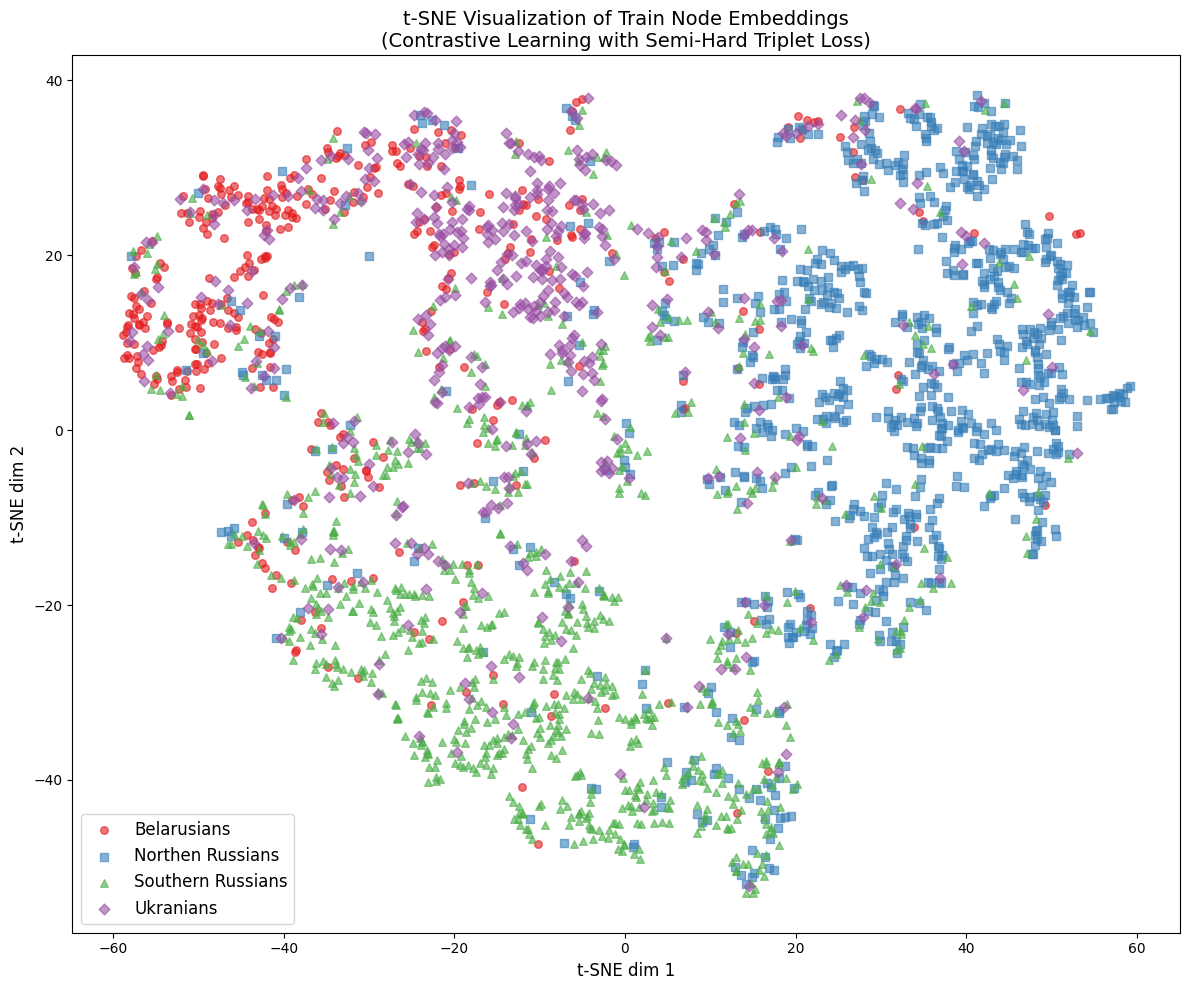

Saved to tsne_triplet_embeddings.png


In [13]:
# Visualize with t-SNE
plt.figure(figsize=(12, 10))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']  # Red, Blue, Green, Purple
markers = ['o', 's', '^', 'D']

for class_idx in range(NUM_CLASSES):
    mask = train_labels_arr == class_idx
    plt.scatter(
        embeddings_2d[mask, 0], 
        embeddings_2d[mask, 1],
        c=colors[class_idx],
        marker=markers[class_idx],
        label=labels[class_idx],
        alpha=0.6,
        s=30
    )

plt.legend(fontsize=12, loc='best')
plt.title('t-SNE Visualization of Train Node Embeddings\n(Contrastive Learning with Semi-Hard Triplet Loss)', fontsize=14)
plt.xlabel('t-SNE dim 1', fontsize=12)
plt.ylabel('t-SNE dim 2', fontsize=12)
plt.tight_layout()
plt.savefig('tsne_triplet_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to tsne_triplet_embeddings.png")
